### load data 

In [1]:
import pandas as pd

patients = pd.read_csv("C:\\Users\\hp\\Desktop\\Septic_shock_prediction\\data\\patients.csv")
admissions = pd.read_csv("C:\\Users\\hp\\Desktop\\Septic_shock_prediction\\data\\admissions.csv")
icustays = pd.read_csv("C:\\Users\\hp\\Desktop\\Septic_shock_prediction\\data\\icustays.csv")

In [3]:
patients.rename(columns={'subject_id':'patient_id'}, inplace=True)
admissions.rename(columns={'subject_id':'patient_id'}, inplace=True)
icustays.rename(columns={'subject_id':'patient_id'}, inplace=True)

In [5]:
patients.head()

,patient_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10014729,F,21,2125,2011 - 2013,NaN
1,10003400,F,72,2134,2011 - 2013,2137-09-02
2,10002428,F,80,2155,2011 - 2013,NaN
3,10032725,F,38,2143,2011 - 2013,2143-03-30
4,10027445,F,48,2142,2011 - 2013,2146-02-09


In [7]:
admissions.head()

,patient_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
0,10004235,24181354,2196-02-24 14:38:00,2196-03-04 14:02:00,NaN,URGENT,P03YMR,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicaid,ENGLISH,SINGLE,BLACK/CAPE VERDEAN,2196-02-24 12:15:00,2196-02-24 17:07:00,0
1,10009628,25926192,2153-09-17 17:08:00,2153-09-25 13:20:00,NaN,URGENT,P41R5N,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicaid,?,MARRIED,HISPANIC/LATINO - PUERTO RICAN,NaN,NaN,0
2,10018081,23983182,2134-08-18 02:02:00,2134-08-23 19:35:00,NaN,URGENT,P233F6,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicare,ENGLISH,MARRIED,WHITE,2134-08-17 16:24:00,2134-08-18 03:15:00,0
3,10006053,22942076,2111-11-13 23:39:00,2111-11-15 17:20:00,2111-11-15 17:20:00,URGENT,P38TI6,TRANSFER FROM HOSPITAL,DIED,Medicaid,ENGLISH,NaN,UNKNOWN,NaN,NaN,1
4,10031404,21606243,2113-08-04 18:46:00,2113-08-06 20:57:00,NaN,URGENT,P07HDB,TRANSFER FROM HOSPITAL,HOME,Other,ENGLISH,WIDOWED,WHITE,NaN,NaN,0


In [9]:
icustays.head()

,patient_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los
0,10018328,23786647,31269608,Neuro Stepdown,Neuro Stepdown,2154-04-24 23:03:44,2154-05-02 15:55:21,7.702512
1,10020187,24104168,37509585,Neuro Surgical Intensive Care Unit (Neuro SICU),Neuro Stepdown,2169-01-15 04:56:00,2169-01-20 15:47:50,5.452662
2,10020187,26842957,32554129,Neuro Intermediate,Neuro Intermediate,2170-02-24 18:18:46,2170-02-25 15:15:26,0.872685
3,10012853,27882036,31338022,Trauma SICU (TSICU),Trauma SICU (TSICU),2176-11-26 02:34:49,2176-11-29 20:58:54,3.766725
4,10020740,25826145,32145159,Trauma SICU (TSICU),Trauma SICU (TSICU),2150-06-03 20:12:32,2150-06-04 21:05:58,1.037106


In [11]:
ITEM_IDS = {
    220045: "heart_rate",
    220179: "bp",
    220210: "resp_rate",
    223761: "temperature"
}

chunks = pd.read_csv("C:\\Users\\hp\\Desktop\\Septic_shock_prediction\\data\\chartevents.csv", chunksize=500000)

vitals_list = []

for chunk in chunks:
    chunk = chunk[chunk['itemid'].isin(ITEM_IDS.keys())]
    chunk = chunk[['subject_id', 'charttime', 'valuenum', 'itemid']]
    vitals_list.append(chunk)

vitals = pd.concat(vitals_list)
vitals['feature'] = vitals['itemid'].map(ITEM_IDS)

In [12]:
labs = pd.read_csv("C:\\Users\\hp\\Desktop\\Septic_shock_prediction\\data\\labevents.csv")

LAB_IDS = {
    50813: "lactate",
    50912: "creatinine",
    51301: "wbc"
}

labs = labs[labs['itemid'].isin(LAB_IDS.keys())]
labs = labs[['subject_id', 'charttime', 'valuenum', 'itemid']]
labs['feature'] = labs['itemid'].map(LAB_IDS)

In [13]:
vitals.rename(columns={'subject_id': 'patient_id'}, inplace=True)
labs.rename(columns={'subject_id': 'patient_id'}, inplace=True)

combined = pd.concat([vitals, labs])
combined['time'] = pd.to_datetime(combined['charttime'])

In [14]:
data = combined.pivot_table(
    index=['patient_id', 'time'],
    columns='feature',
    values='valuenum'
).reset_index()

In [19]:
data.head()

feature,patient_id,time,bp,creatinine,heart_rate,lactate,resp_rate,temperature,wbc
0,10000032,2180-03-23 11:51:00,NaN,0.4,NaN,NaN,NaN,NaN,3.0
1,10000032,2180-05-06 22:25:00,NaN,0.3,NaN,NaN,NaN,NaN,5.0
2,10000032,2180-05-07 05:05:00,NaN,0.3,NaN,NaN,NaN,NaN,4.2
3,10000032,2180-06-03 12:00:00,NaN,0.4,NaN,NaN,NaN,NaN,NaN
4,10000032,2180-06-22 11:15:00,NaN,0.3,NaN,NaN,NaN,NaN,5.1


In [21]:
data['label'] = (
    (data['bp'] < 90) |
    (data['lactate'] > 2.5) |
    (data['heart_rate'] > 110)
).astype(int)

In [23]:
from sklearn.utils import resample

df_major = data[data.label == 0]
df_minor = data[data.label == 1]

df_minor_up = resample(
    df_minor,
    replace=True,
    n_samples=len(df_major),
    random_state=42
)

data_balanced = pd.concat([df_major, df_minor_up])

In [25]:
print(data['label'].value_counts())

0    19622
1     3038
Name: label, dtype: int64


In [26]:
data.head()

feature,patient_id,time,bp,creatinine,heart_rate,lactate,resp_rate,temperature,wbc,label
0,10000032,2180-03-23 11:51:00,NaN,0.4,NaN,NaN,NaN,NaN,3.0,0
1,10000032,2180-05-06 22:25:00,NaN,0.3,NaN,NaN,NaN,NaN,5.0,0
2,10000032,2180-05-07 05:05:00,NaN,0.3,NaN,NaN,NaN,NaN,4.2,0
3,10000032,2180-06-03 12:00:00,NaN,0.4,NaN,NaN,NaN,NaN,NaN,0
4,10000032,2180-06-22 11:15:00,NaN,0.3,NaN,NaN,NaN,NaN,5.1,0


In [27]:
data = (
    data.sort_values(['patient_id', 'time'])
        .groupby('patient_id', as_index=False)
        .apply(lambda x: x.ffill())
        .reset_index(drop=True)
)

C:\Users\hp\AppData\Local\Temp\ipykernel_3832\2365208375.py:4: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  .apply(lambda x: x.ffill())


In [32]:
# Fill remaining NaNs
data = data.fillna(data.mean())
data.head()

C:\Users\hp\AppData\Local\Temp\ipykernel_3832\902231920.py:2: FutureWarning: DataFrame.mean and DataFrame.median with numeric_only=None will include datetime64 and datetime64tz columns in a future version.
  data = data.fillna(data.mean())


feature,patient_id,time,bp,creatinine,heart_rate,lactate,resp_rate,temperature,wbc,label
0,10000032,2180-03-23 11:51:00,112.321986,0.4,91.273814,1.949337,20.110023,98.461647,3.0,0
1,10000032,2180-05-06 22:25:00,112.321986,0.3,91.273814,1.949337,20.110023,98.461647,5.0,0
2,10000032,2180-05-07 05:05:00,112.321986,0.3,91.273814,1.949337,20.110023,98.461647,4.2,0
3,10000032,2180-06-03 12:00:00,112.321986,0.4,91.273814,1.949337,20.110023,98.461647,4.2,0
4,10000032,2180-06-22 11:15:00,112.321986,0.3,91.273814,1.949337,20.110023,98.461647,5.1,0


In [34]:
print(data.isnull().sum())
print(data.shape)
data.head()

feature
patient_id     0
time           0
bp             0
creatinine     0
heart_rate     0
lactate        0
resp_rate      0
temperature    0
wbc            0
label          0
dtype: int64
(22660, 10)


feature,patient_id,time,bp,creatinine,heart_rate,lactate,resp_rate,temperature,wbc,label
0,10000032,2180-03-23 11:51:00,112.321986,0.4,91.273814,1.949337,20.110023,98.461647,3.0,0
1,10000032,2180-05-06 22:25:00,112.321986,0.3,91.273814,1.949337,20.110023,98.461647,5.0,0
2,10000032,2180-05-07 05:05:00,112.321986,0.3,91.273814,1.949337,20.110023,98.461647,4.2,0
3,10000032,2180-06-03 12:00:00,112.321986,0.4,91.273814,1.949337,20.110023,98.461647,4.2,0
4,10000032,2180-06-22 11:15:00,112.321986,0.3,91.273814,1.949337,20.110023,98.461647,5.1,0


In [36]:
# Prepare patients table
patients_age = patients[['patient_id', 'anchor_age']].copy()


# Merge
data = data.merge(patients_age, on='patient_id', how='left')

# Rename
data.rename(columns={'anchor_age': 'age'}, inplace=True)

In [38]:
print(data.isnull().sum())

patient_id     0
time           0
bp             0
creatinine     0
heart_rate     0
lactate        0
resp_rate      0
temperature    0
wbc            0
label          0
age            0
dtype: int64


In [40]:
features = data[['bp','creatinine','heart_rate','lactate','resp_rate','temperature','wbc','age']]
target = data['label']

In [42]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
features_scaled = scaler.fit_transform(features)

In [44]:
import pickle
pickle.dump(scaler, open("scaler.pkl", "wb"))

In [46]:
import numpy as np
import pandas as pd

SEQ_LENGTH = 24

def create_sequences(features, target, patient_ids):
    X, y = [], []

    df = pd.DataFrame(features)
    df['label'] = target.values
    df['patient_id'] = patient_ids.values

    for pid in df['patient_id'].unique():
        temp = df[df['patient_id'] == pid]

        if len(temp) < SEQ_LENGTH:
            continue  # skip small data (important fix)

        for i in range(len(temp) - SEQ_LENGTH):
            X.append(
                temp.iloc[i:i+SEQ_LENGTH]
                .drop(['label','patient_id'], axis=1)
                .values
            )
            y.append(temp.iloc[i+SEQ_LENGTH]['label'])

    return np.array(X), np.array(y)

X, y = create_sequences(features_scaled, target, data['patient_id'])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20274, 24, 8)
y shape: (20274,)


In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [51]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, Bidirectional, LSTM,
    Dense, Dropout, Attention,
    GlobalAveragePooling1D
)

def build_model():
    inputs = Input(shape=(24, 8))

    # CNN
    x = Conv1D(64, 3, padding='same', activation='relu')(inputs)

    # BiLSTM
    x = Bidirectional(LSTM(64, return_sequences=True))(x)

    # Attention
    attn_output = Attention()([x, x])

    # Pooling
    x = GlobalAveragePooling1D()(attn_output)

    # Dense
    x = Dense(32, activation='relu')(x)
    x = Dropout(0.3)(x)

    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

model = build_model()
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 24, 8)]              0         []                            
                                                                                                  
 conv1d (Conv1D)             (None, 24, 64)               1600      ['input_1[0][0]']             
                                                                                                  
 bidirectional (Bidirection  (None, 24, 128)              66048     ['conv1d[0][0]']              
 al)                                                                                              
                                                                                                  
 attention (Attention)       (None, 24, 128)              0         ['bidirectional[0][0]',   

In [53]:
model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    
)

Epoch 1/20
406/406 [==============================] - 13s 19ms/step - loss: 0.3464 - accuracy: 0.8684 - val_loss: 0.3019 - val_accuracy: 0.8727
Epoch 2/20
406/406 [==============================] - 6s 16ms/step - loss: 0.3073 - accuracy: 0.8701 - val_loss: 0.2959 - val_accuracy: 0.8819
Epoch 3/20
406/406 [==============================] - 9s 22ms/step - loss: 0.2979 - accuracy: 0.8770 - val_loss: 0.3053 - val_accuracy: 0.8684
Epoch 4/20
406/406 [==============================] - 7s 18ms/step - loss: 0.2936 - accuracy: 0.8749 - val_loss: 0.3258 - val_accuracy: 0.8715
Epoch 5/20
406/406 [==============================] - 8s 19ms/step - loss: 0.2899 - accuracy: 0.8782 - val_loss: 0.2811 - val_accuracy: 0.8841
Epoch 6/20
406/406 [==============================] - 8s 19ms/step - loss: 0.2860 - accuracy: 0.8789 - val_loss: 0.2964 - val_accuracy: 0.8628
Epoch 7/20
406/406 [==============================] - 10s 24ms/step - loss: 0.2867 - accuracy: 0.8775 - val_loss: 0.2783 - val_accuracy: 0.88

In [68]:
model.save("C:\\Users\\hp\\Desktop\\Septic_shock_prediction\\advanced_model.keras")

C:\Users\hp\anaconda3\envs\septic_final\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2/2 [==============================] - 1s 8ms/step


  0%|          | 0/1 [00:00<?, ?it/s]

3800/3800 [==============================] - 33s 9ms/step


100%|██████████| 1/1 [00:36<00:00, 36.27s/it]


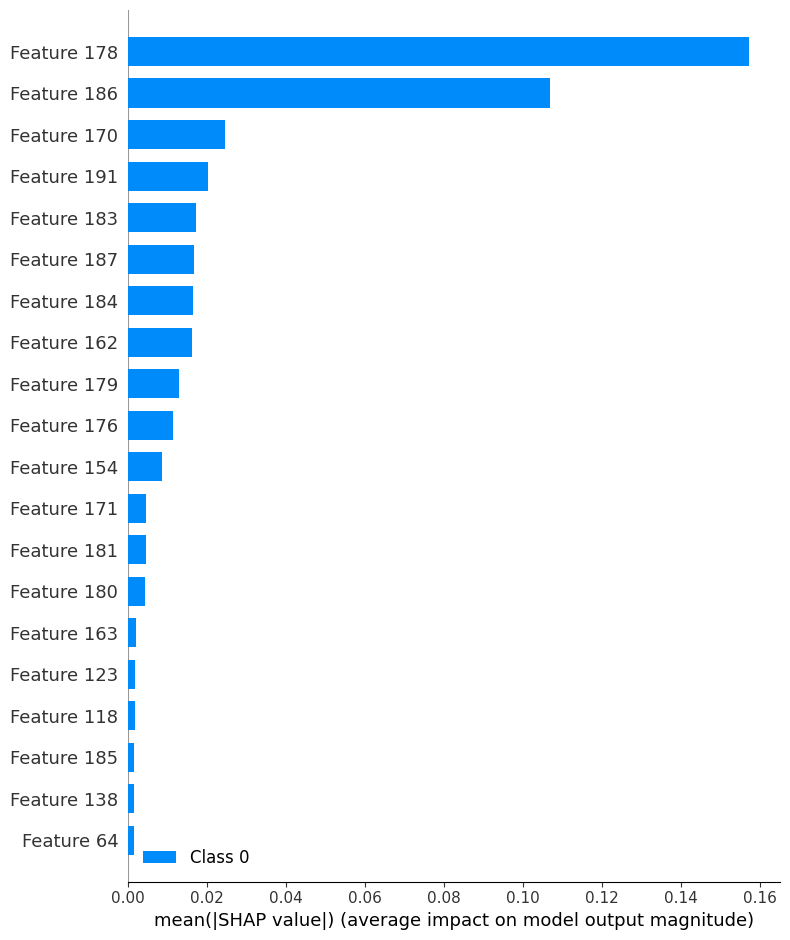

In [57]:
import numpy as np
np.int = int
import shap


# Flatten data
background = X_train[:50].reshape(50, -1)
sample = X_test[0:1].reshape(1, -1)

# Wrapper for model
def predict_fn(x):
    return model.predict(x.reshape(-1, 24, 8))

# SHAP
explainer = shap.KernelExplainer(predict_fn, background)
shap_values = explainer.shap_values(sample)

# Plot
shap.summary_plot(shap_values, sample)

In [59]:
loss, acc = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", acc)

127/127 [==============================] - 1s 10ms/step - loss: 0.2816 - accuracy: 0.8801
Test Loss: 0.2815536558628082
Test Accuracy: 0.8801479935646057


In [61]:
pred = model.predict(X_test)

# Convert probabilities to 0/1
pred_labels = (pred > 0.5).astype(int)

127/127 [==============================] - 1s 6ms/step


In [63]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, pred_labels))
print(classification_report(y_test, pred_labels))

[[3342  121]
 [ 365  227]]
              precision    recall  f1-score   support

         0.0       0.90      0.97      0.93      3463
         1.0       0.65      0.38      0.48       592

    accuracy                           0.88      4055
   macro avg       0.78      0.67      0.71      4055
weighted avg       0.87      0.88      0.87      4055



In [65]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, pred)
print("AUROC:", auc)

AUROC: 0.8778808407020938
